In [1]:
# load this dataset and show its columns: C:\Users\Mohammad Reza\OneDrive - Politecnico di Milano\Showreel\Data_Cleaned\yt_videos_with_local_transcripts.parquet
import pandas as pd
# Load the dataset
file_path = r"C:\Users\Mohammad Reza\OneDrive - Politecnico di Milano\Showreel\Data_Cleaned\yt_videos_with_local_transcripts.parquet"
df = pd.read_parquet(file_path)
# Show the columns of the dataset
print(df.columns)

Index(['thumbnail_default_url', 'videoId', 'publishedAt', 'channelId',
       'channelTitle', 'title', 'description', 'tags', 'categoryId',
       'defaultLanguage', 'defaultAudioLanguage', 'definition', 'caption',
       'licensedContent', 'regionRestriction_blocked', 'license', 'embeddable',
       'madeForKids', 'viewCount', 'likeCount', 'commentCount', 'is_short',
       'is_hd', 'topic_labels_extracted', 'duration_seconds',
       'thumbnail_maxres_url', 'thumbnail_high_url', 'transcript',
       'local_transcript'],
      dtype='str')


In [3]:
# show the first 5 rows of the dataset in a table view
df.head()

,thumbnail_default_url,videoId,publishedAt,channelId,channelTitle,title,description,tags,categoryId,defaultLanguage,...,likeCount,commentCount,is_short,is_hd,topic_labels_extracted,duration_seconds,thumbnail_maxres_url,thumbnail_high_url,transcript,local_transcript
0,https://i.ytimg.com/vi/eNU5FcmEwTc/default.jpg,eNU5FcmEwTc,2026-02-27 14:16:42+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,ChatGPT non ha aiutato...,NaN,NaN,22,it,...,55.0,0.0,True,1.0,Entertainment,42.0,https://i.ytimg.com/vi/eNU5FcmEwTc/maxresdefau...,https://i.ytimg.com/vi/eNU5FcmEwTc/hqdefault.jpg,"Allora, eh questo è molto piccolo, è veramente...","Allora, eh questo è molto piccolo, è veramente..."
1,https://i.ytimg.com/vi/tNbsrpKaMoE/default.jpg,tNbsrpKaMoE,2026-02-26 13:18:36+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,TIER LIST - Sanremo Edition con @willwoosh,"Il video è ironico, per le informazioni sui ca...",NaN,22,it,...,2563.0,78.0,False,1.0,Entertainment,978.0,https://i.ytimg.com/vi/tNbsrpKaMoE/maxresdefau...,https://i.ytimg.com/vi/tNbsrpKaMoE/hqdefault.jpg,"Ciao amici, oggi faremo una tierlist con un os...",Kind: captions Language: it align:start positi...
2,https://i.ytimg.com/vi/80cTxK_fA_Q/default.jpg,80cTxK_fA_Q,2026-02-25 12:00:28+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,Dirò una cosa forte!!!,NaN,NaN,22,it,...,422.0,9.0,True,1.0,Lifestyle (sociology),63.0,https://i.ytimg.com/vi/80cTxK_fA_Q/maxresdefau...,https://i.ytimg.com/vi/80cTxK_fA_Q/hqdefault.jpg,dirò una cosa forte. Io se dovessi fare il fig...,dirò una cosa forte. Io se dovessi fare il fig...
3,https://i.ytimg.com/vi/AS6paOwhdR0/default.jpg,AS6paOwhdR0,2026-02-23 12:00:28+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,Voi cose pensate quando qualcuno non vi rispon...,NaN,NaN,22,it,...,141.0,3.0,True,1.0,Lifestyle (sociology),60.0,https://i.ytimg.com/vi/AS6paOwhdR0/maxresdefau...,https://i.ytimg.com/vi/AS6paOwhdR0/hqdefault.jpg,cercare di disintossicarmi dalla validazione d...,cercare di disintossicarmi dalla validazione d...
4,https://i.ytimg.com/vi/wPFcvFEPSSQ/default.jpg,wPFcvFEPSSQ,2026-02-20 12:01:39+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,"Mai avere paura delle risposte, mai più!",NaN,NaN,22,it,...,163.0,3.0,True,1.0,Lifestyle (sociology),61.0,https://i.ytimg.com/vi/wPFcvFEPSSQ/maxresdefau...,https://i.ytimg.com/vi/wPFcvFEPSSQ/hqdefault.jpg,Una cosa su cui ho lavorato molto in terapia q...,Una cosa su cui ho lavorato molto in terapia q...


publishedAt dtype before conversion: str
publishedAt dtype after conversion: datetime64[us]


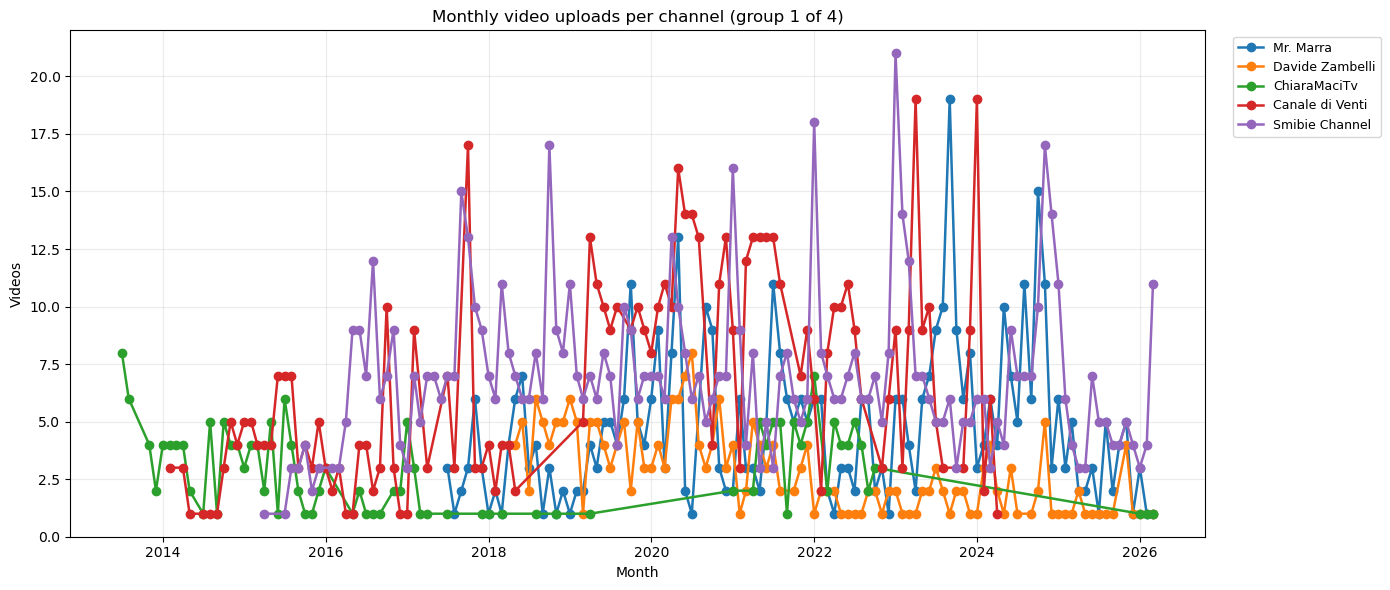

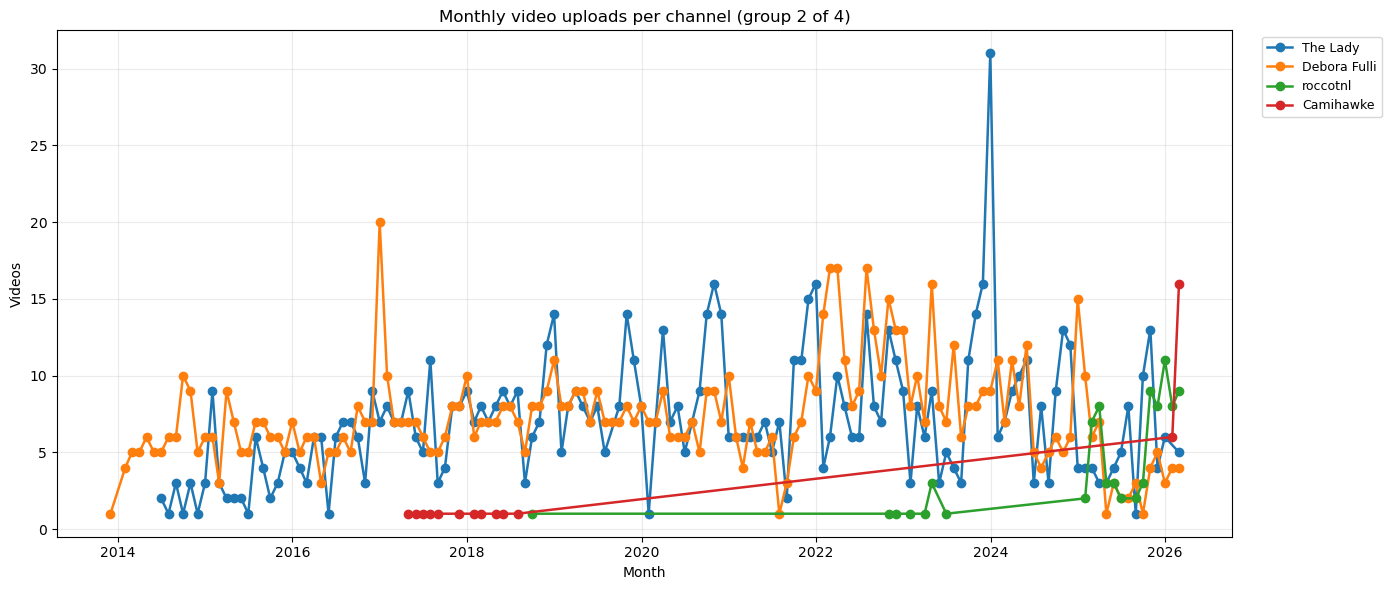

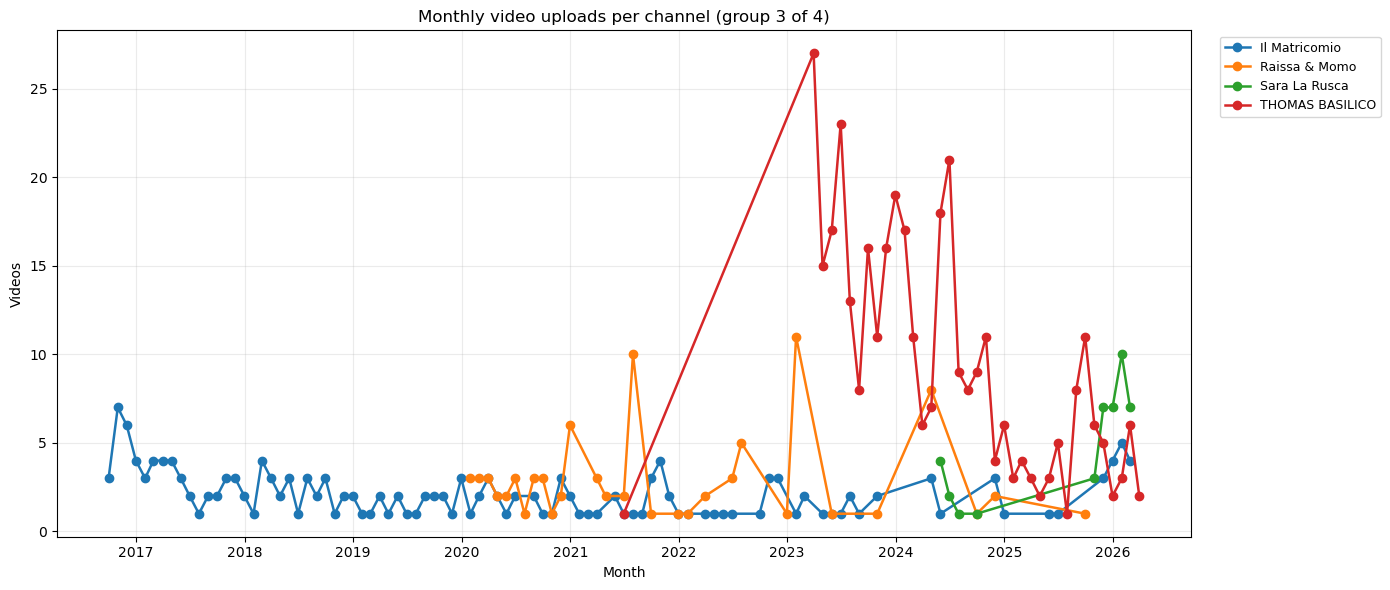

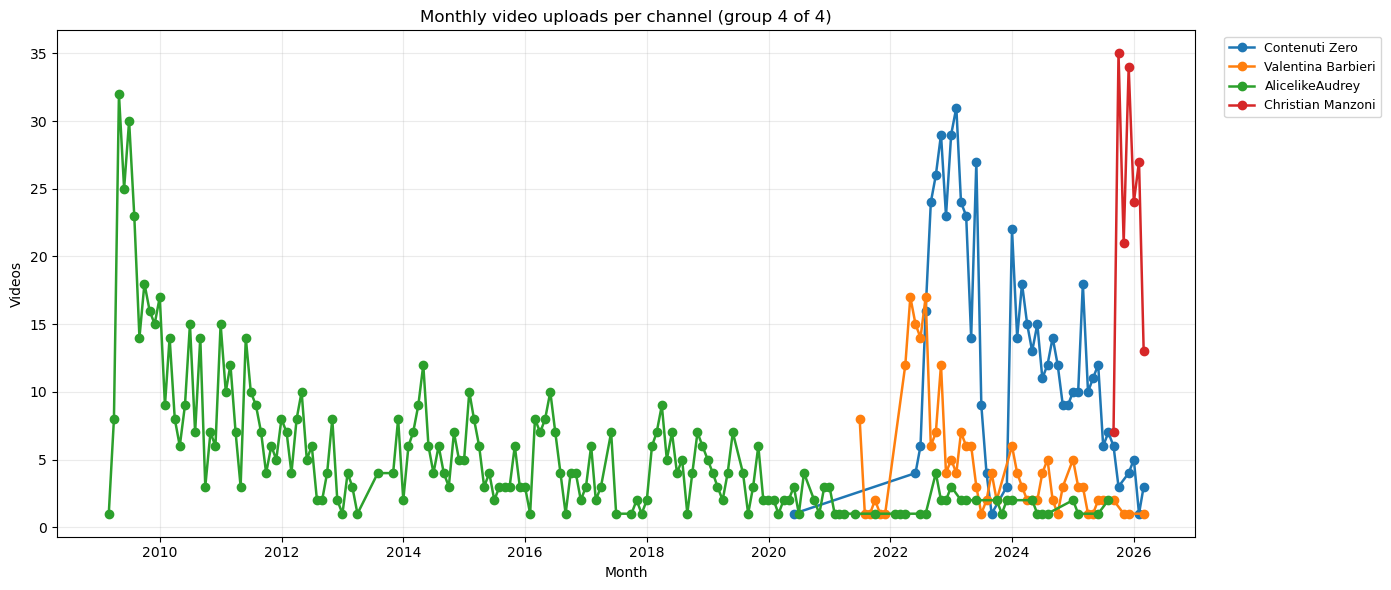

In [11]:
# create a time series of the number of videos uploaded per month for this list of channels, and plot it
import pandas as pd
import matplotlib.pyplot as plt

channels = [
    "Mr. Marra",
    "Davide Zambelli",
    "ChiaraMaciTv",
    "Canale di Venti",
    "Smibie Channel",
    "The Lady",
    "Debora Fulli",
    "roccotnl",
    "Camihawke",
    "Il Matricomio",
    "Raissa & Momo",
    "Sara La Rusca",
    "THOMAS BASILICO",
    "Contenuti Zero",
    "Valentina Barbieri",
    "AlicelikeAudrey",
    "Christian Manzoni",
]

# Reload the parquet so this cell does not depend on stale notebook state
plot_df = pd.read_parquet(file_path)

# Detect the needed columns
author_col = next((col for col in ["channelTitle", "channel_title", "channelName", "uploader"] if col in plot_df.columns), None)
date_col = next((col for col in ["publishedAt", "upload_date", "published_at"] if col in plot_df.columns), None)
if author_col is None:
    raise KeyError(f"No expected channel column found. Available columns: {list(plot_df.columns)}")
if date_col is None:
    raise KeyError(f"No expected date column found. Available columns: {list(plot_df.columns)}")

# Figure out the dtype and normalize it to timezone-naive datetime
print(f"{date_col} dtype before conversion: {plot_df[date_col].dtype}")
plot_df[date_col] = pd.to_datetime(plot_df[date_col], errors='coerce', utc=True)
plot_df[date_col] = plot_df[date_col].dt.tz_convert(None)
print(f"{date_col} dtype after conversion: {plot_df[date_col].dtype}")

# Keep only the requested channels and build monthly counts
plot_df = plot_df[plot_df[author_col].isin(channels)].copy()
plot_df = plot_df.dropna(subset=[date_col])
plot_df["month"] = plot_df[date_col].dt.to_period("M").dt.to_timestamp("M")
monthly_counts = (
    plot_df.groupby([author_col, "month"]).size().reset_index(name="videos")
)

# Use a small number of multi-line plots instead of one panel per channel
plot_groups = [
    ["Mr. Marra", "Davide Zambelli", "ChiaraMaciTv", "Canale di Venti", "Smibie Channel"],
    ["The Lady", "Debora Fulli", "roccotnl", "Camihawke"],
    ["Il Matricomio", "Raissa & Momo", "Sara La Rusca", "THOMAS BASILICO"],
    ["Contenuti Zero", "Valentina Barbieri", "AlicelikeAudrey", "Christian Manzoni"],
]

for group_index, group in enumerate(plot_groups, start=1):
    fig, ax = plt.subplots(figsize=(14, 6))
    for channel in group:
        channel_series = monthly_counts[monthly_counts[author_col] == channel].sort_values("month")
        ax.plot(channel_series["month"], channel_series["videos"], marker="o", linewidth=1.8, label=channel)

    ax.set_title(f"Monthly video uploads per channel (group {group_index} of {len(plot_groups)})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Videos")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
# 